##### Author: Pablo Iañez Picazo
##### Biomedical Data Science lab

In [2]:
# Load all the necessary libraries
import gc
from glob import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from skimage import measure

from statannotations.Annotator import Annotator

# Supress all warnings
import warnings

warnings.filterwarnings("ignore")

from hsc_spatial_stats import *

In [5]:
def fix_labels(df):
    """
    Fix the label for each HSC biological condition in the dataframe from the
    folder ID name to new names for plotting
    """

    labels_dict = {
        "young": "Young",
        "old": "Aged",
        "treated_RhoAi": "Aged + Ri",
        "compressed_8um": "8μm",
        "compressed_5um": "5μm",
        "compressed_3um": "3μm",
    }

    for old, new in labels_dict.items():
        df["condition"] = [c.replace(old, new) for c in df["condition"]]

    return df


def get_nuclear_metrics_2D_slide(mask, im, res):
    """
    Extract intensity measures and morphometrical measures from the given 2D
    slide, along with the nuclear mask
    """

    properties_slide = [
        "area",
        "bbox",
        "centroid",
        "eccentricity",
        "major_axis_length",
        "minor_axis_length",
        "perimeter",
        "perimeter_crofton",
        "equivalent_diameter",
        "feret_diameter_max",
    ]

    label_mask = measure.label(mask)

    # Extract basic features using skimage regionprops
    df = pd.DataFrame(
        measure.regionprops_table(
            label_mask, intensity_image=im, properties=properties_slide
        )
    )

    # turn pixel units into micrometer units
    for m in [
        "equivalent_diameter",
        "feret_diameter_max",
        "major_axis_length",
        "minor_axis_length",
        "perimeter",
        "perimeter_crofton",
    ]:
        df[m] = df[m] * res

    # Compute more features
    df["area"] = df["area"] * (res**2)
    roundness = 4.0 * np.pi * df["area"] / df["perimeter"] ** 2
    df["roundness"] = min(1.0, roundness.values[0])
    df["compactness"] = df["perimeter"] ** (2 / (4.0 * np.pi * df["area"]))
    df["EOP"] = excess_of_perimeter_ellipse(df)

    return df

In [3]:
# ---------------------- Set up processing parameters ---------------------- #

# Image resolution after resizing, which is 5 micrometers per pixel
res = 0.1

# cluster forming threshold - threshold at which intensities above this value
# will be considered belonging to a DAPI-Intense Region (DIR)
# Intensities to 0.6 are the one in the quantile 0.80 in young, old and treated
cft = 0.6
normalization = "z_score"
folder = "data"
conditions = [
    "young",
    "old",
    "treated_RhoAi",
    "compressed_8um",
    "compressed_5um",
    "compressed_3um",
    "treated_NaB",
    "RhoA_KO",
]

In [6]:
nuc_df = pd.DataFrame()
conditions = ["compressed_5um", "compressed_3um", "treated_NaB", "RhoA_KO"]

for cond in conditions:
    # Lists .npz files within containing folder with a given prefix
    npz_ims = glob(f"{folder}/res_{res}_{normalization}_norm/{cond}/*.npz")
    print(cond)

    for i, npz in enumerate(npz_ims):
        print(i)
        image = np.load(npz)
        nuc_mask = image["seg"].astype(int)
        im = image["dapi"]

        # Rotate the image and convert to XYZ coordenates
        im, nuc_mask = from_zxy_to_xyz([im, nuc_mask])

        # max_index = np.argmax(nuc_mask.sum(0).sum(0))
        # plt.imshow(im[:, :, max_index], vmin=-2, vmax=5)
        # plt.show()

        df = get_nuclear_metrics_3D(nuc_mask, im, res)

        # Add information from the largest 2D slide in XY plane
        slide, slide_mask = get_slide(im, nuc_mask, mode="largest", plane="XY")
        slide, slide_mask = [np.rot90(a) for a in (slide, slide_mask)]
        df_slide = get_nuclear_metrics_2D_slide(slide_mask, slide, res)
        df_slide = df_slide.add_prefix("2D_slide_")
        df = pd.concat([df, df_slide], axis=1)

        # Segment with Watershed algorithm
        DIRs_mask = segment_condensates(
            im, nuc_mask, cluster_thresh=cft, mode="absolute"
        )
        # plt.imshow(DIRs_mask[:, :, max_index])
        # plt.show()

        # If here is at least one segmented DIR
        if not np.count_nonzero(DIRs_mask) == 0:
            df_DIRs = get_DIRs_metrics_3D(DIRs_mask, im, res)
            DIRs_mask, df_DIRs = filter_DIRs(
                DIRs_mask, df_DIRs, query="include == False or volume < 0.2"
            )

            # ---------gets distance near nuclear border
            dist2bord = distance_transform_edt(nuc_mask)

            # ------------calculates and tabulates distance to edge of each single
            # DIR in the properties table
            df_DIRs = get_distance_to_edge_by_DIR(df_DIRs, dist2bord, DIRs_mask)

            # Do the average of all DAPI Intense Regions (DIRs) in this nucleus
            df_DIRs = pd.DataFrame(df_DIRs.mean(axis=0)).T
            df_DIRs = df_DIRs.add_prefix("DIRs_")
            df = pd.concat([df, df_DIRs], axis=1)

        # Add image path and batch for identification later on
        df["im_path"] = npz[18:]
        df["im_batch"] = npz[-23:-8]
        df["condition"] = cond

        # Merge the nucleus and DIRs dataframe into one and save this iteration
        nuc_df = pd.concat([nuc_df, df])
        gc.collect()

    nuc_df.to_csv(f"results/ZSCORENORM_nuclei_3d_res{res}_cf{cft}_df.csv")

# Filter if there was more than one mask in the image
nuc_df["n_masks"] = nuc_df.index
nuc_df = nuc_df.query("n_masks == 0")
nuc_df = nuc_df.reset_index(drop=True)
nuc_df = fix_labels(nuc_df)

nuc_df

compressed_5um
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
compressed_3um
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
treated_NaB
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
RhoA_KO
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78


,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,centroid-0,centroid-1,centroid-2,weighted_centroid-0,...,DIRs_domain_num,DIRs_include,DIRs_n,DIRs_centroid_distance2border,DIRs_mean_distance2border,DIRs_min_distance2border,im_path,im_batch,condition,n_masks
0,3,3,3,76,69,71,38.039543,36.246856,33.666202,-5.816293e+15,...,11.882353,1.0,17.0,7.185210,6.477286,3.012964,res_0.1_z_score_norm/young/Image_17_20201218ex...,8expY1RhoAAF488,Young,0
1,3,3,3,61,57,63,31.143018,28.433366,30.519093,-1.619139e+15,...,3.500000,1.0,6.0,9.966062,8.093383,2.745356,res_0.1_z_score_norm/young/Image_25_20191219Pl...,de11exp20191209,Young,0
2,3,3,3,78,75,79,41.065375,38.251521,39.858922,-8.112989e+16,...,23.580645,1.0,31.0,6.287188,5.774141,2.533929,res_0.1_z_score_norm/young/Image_14_20220502_2...,oAGTPCy3H4K16ac,Young,0
3,3,3,3,73,68,79,39.572429,31.651126,38.197374,5.505775e+15,...,17.347826,1.0,23.0,8.805422,7.731984,3.545110,res_0.1_z_score_norm/young/Image_12_Y_220427_2...,exp_YRhoAGTPCy3,Young,0
4,3,3,3,78,71,65,39.406352,37.852106,30.815409,4.415593e+15,...,19.720000,1.0,25.0,7.731574,7.079325,3.069802,res_0.1_z_score_norm/young/Image_61_20201119ex...,gRFPcellsSlide3,Young,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,3,3,3,76,75,85,38.385554,38.855553,39.801277,6.824016e+15,...,15.240000,1.0,25.0,11.785688,10.834546,5.161541,res_0.1_z_score_norm/RhoA_KO/Image_70_20210701...,oAKOexpEXPNOTAM,RhoA KO,0
650,3,3,3,65,60,71,34.766129,30.980095,39.906516,2.789341e+15,...,15.913043,1.0,23.0,7.285607,6.548100,2.595071,res_0.1_z_score_norm/RhoA_KO/Image_75_20210701...,-TAMTAZ20210729,RhoA KO,0
651,3,3,3,79,68,85,43.008086,33.871821,42.743194,6.052157e+15,...,14.863636,1.0,22.0,8.790699,8.022762,4.325301,res_0.1_z_score_norm/RhoA_KO/Image_87_20210701...,+TAMTAZ20210729,RhoA KO,0
652,3,3,3,70,79,81,35.975543,38.831315,40.553695,2.946728e+14,...,18.583333,1.0,24.0,6.716760,5.907373,2.545754,res_0.1_z_score_norm/RhoA_KO/Image_92_20210701...,+TAMTAZ20210729,RhoA KO,0


In [7]:
# Identify images that were not standardized properly
nuc_df.query('mean_intensity > 0.001 or mean_intensity < -0.001')

,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,centroid-0,centroid-1,centroid-2,weighted_centroid-0,...,DIRs_domain_num,DIRs_include,DIRs_n,DIRs_centroid_distance2border,DIRs_mean_distance2border,DIRs_min_distance2border,im_path,im_batch,condition,n_masks
360,3,60,3,16,91,13,8.446714,74.603020,7.481350,7.681910,...,13.647059,1.0,17.0,7.895764,6.953587,3.204880,res_0.1_z_score_norm/treated_RhoAi/Image_43_20...,ide9A1+RiTazCy3,Aged + Ri,0
450,3,3,3,11,27,45,5.452689,14.897908,26.393924,3.609843,...,15.550000,1.0,20.0,9.031853,8.118552,3.727843,res_0.1_z_score_norm/compressed_8um/Image_2_8u...,15_8umRhoGTPTAZ,8μm,0
464,3,3,9,64,72,75,32.585443,37.464533,38.934127,33.012200,...,13.875000,1.0,16.0,10.984611,10.142530,5.092111,res_0.1_z_score_norm/compressed_8um/Image_62_8...,TAZlooks_like_8,8μm,0
505,3,3,3,55,37,36,24.606832,24.774056,25.971161,-1398.267819,...,1.500000,1.0,2.0,4.500000,3.443945,1.000000,res_0.1_z_score_norm/compressed_3um/3micron021...,20216wt_RhoACy3,3μm,0


<AxesSubplot:xlabel='volume', ylabel='condition'>

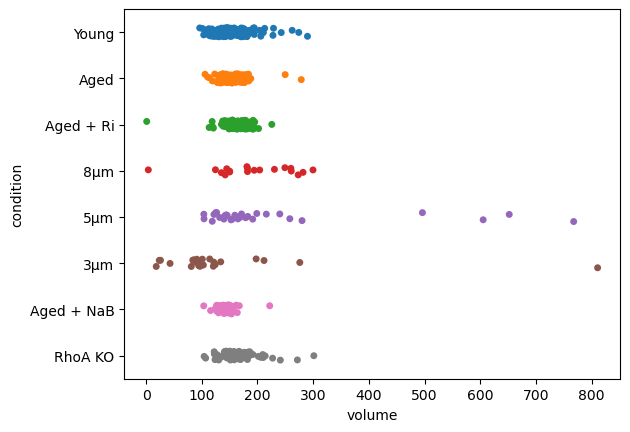

In [11]:
sns.stripplot(data=nuc_df, x="volume", y="condition", dodge=True, zorder=1)

In [12]:
# Identify the "splashed cells" that occupy the whole image grid
nuc_df.query('volume > 400')

,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,centroid-0,centroid-1,centroid-2,weighted_centroid-0,...,DIRs_domain_num,DIRs_include,DIRs_n,DIRs_centroid_distance2border,DIRs_mean_distance2border,DIRs_min_distance2border,im_path,im_batch,condition,n_masks
475,3,3,3,138,138,41,70.248010,68.993911,23.821843,2.423652e+14,...,67.705882,1.0,17.0,10.417159,7.566927,1.890527,res_0.1_z_score_norm/compressed_5um/Image_1_5u...,3_5umRhoGTPTAZ_,5μm,0
478,3,3,3,138,138,44,69.979905,69.554461,25.580019,8.033698e+15,...,224.361111,1.0,36.0,5.333333,5.653258,2.982518,res_0.1_z_score_norm/compressed_5um/Image_4_5u...,3_5umRhoGTPTAZ_,5μm,0
479,3,3,3,138,138,34,69.822431,69.575616,19.841197,-1.836271e+16,...,138.600000,1.0,30.0,5.833333,4.627610,1.444152,res_0.1_z_score_norm/compressed_5um/Image_7_5u...,3_5umRhoGTPTAZ_,5μm,0
496,3,3,3,138,138,58,70.216710,69.228593,36.042217,-1.292075e+15,...,161.392857,1.0,28.0,8.346206,7.453957,2.883559,res_0.1_z_score_norm/compressed_5um/Image_5_5u...,3_5umRhoGTPTAZ_,5μm,0
524,3,3,3,138,138,60,69.925884,69.823028,37.195241,2.616251e+16,...,173.000000,1.0,1.0,24.000000,14.040921,1.000000,res_0.1_z_score_norm/compressed_3um/3micron031...,control_RhoACy3,3μm,0


In [13]:
# Remove artifacts created by the segmentation which are too small to be nuclei
# these are exactly the images that were not standardized properly
nuc_df.query('volume < 50')

,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,centroid-0,centroid-1,centroid-2,weighted_centroid-0,...,DIRs_domain_num,DIRs_include,DIRs_n,DIRs_centroid_distance2border,DIRs_mean_distance2border,DIRs_min_distance2border,im_path,im_batch,condition,n_masks
360,3,60,3,16,91,13,8.446714,74.603020,7.481350,7.681910e+00,...,13.647059,1.0,17.0,7.895764,6.953587,3.204880,res_0.1_z_score_norm/treated_RhoAi/Image_43_20...,ide9A1+RiTazCy3,Aged + Ri,0
450,3,3,3,11,27,45,5.452689,14.897908,26.393924,3.609843e+00,...,15.550000,1.0,20.0,9.031853,8.118552,3.727843,res_0.1_z_score_norm/compressed_8um/Image_2_8u...,15_8umRhoGTPTAZ,8μm,0
500,3,3,3,64,91,35,33.767975,47.287476,15.254768,5.318314e+16,...,6.500000,1.0,10.0,7.843125,6.001218,2.739194,res_0.1_z_score_norm/compressed_3um/3micron021...,20216wt_RhoACy3,3μm,0
503,3,3,3,53,52,47,30.151736,25.658551,25.448458,-2.933315e+16,...,4.000000,1.0,7.0,5.607006,4.243400,2.219519,res_0.1_z_score_norm/compressed_3um/3micron031...,control_RhoACy3,3μm,0
505,3,3,3,55,37,36,24.606832,24.774056,25.971161,-1.398268e+03,...,1.500000,1.0,2.0,4.500000,3.443945,1.000000,res_0.1_z_score_norm/compressed_3um/3micron021...,20216wt_RhoACy3,3μm,0
522,3,3,3,51,42,43,26.532407,22.564659,19.210082,-5.197969e+15,...,2.500000,1.0,4.0,7.887660,5.997032,2.378496,res_0.1_z_score_norm/compressed_3um/3micron031...,control_RhoACy3,3μm,0


In [14]:
# Three of these are also images with volume > 400
nuc_df.query('DIRs_volume > 5')

,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,centroid-0,centroid-1,centroid-2,weighted_centroid-0,...,DIRs_domain_num,DIRs_include,DIRs_n,DIRs_centroid_distance2border,DIRs_mean_distance2border,DIRs_min_distance2border,im_path,im_batch,condition,n_masks
455,3,3,3,82,70,75,43.028750,36.999475,34.546402,4.299627e+15,...,9.833333,1.0,6.0,13.930875,12.012886,4.499017,res_0.1_z_score_norm/compressed_8um/Image_1_8u...,15_8umRhoGTPTAZ,8μm,0
475,3,3,3,138,138,41,70.248010,68.993911,23.821843,2.423652e+14,...,67.705882,1.0,17.0,10.417159,7.566927,1.890527,res_0.1_z_score_norm/compressed_5um/Image_1_5u...,3_5umRhoGTPTAZ_,5μm,0
482,3,3,3,85,106,48,42.844871,54.154165,22.711282,-5.298611e+15,...,4.500000,1.0,4.0,16.326912,12.127961,3.704786,res_0.1_z_score_norm/compressed_5um/Image_15_5...,20519_conf4.8_2,5μm,0
488,3,3,3,101,101,54,50.872085,53.410811,26.299079,-3.358619e+16,...,11.000000,1.0,12.0,12.004084,9.980159,3.703656,res_0.1_z_score_norm/compressed_5um/Image_13_5...,20519_conf4.8_2,5μm,0
524,3,3,3,138,138,60,69.925884,69.823028,37.195241,2.616251e+16,...,173.000000,1.0,1.0,24.000000,14.040921,1.000000,res_0.1_z_score_norm/compressed_3um/3micron031...,control_RhoACy3,3μm,0


In [15]:
nuc_df = nuc_df.query('volume > 50 and volume < 400 and DIRs_volume < 5')

In [16]:
nuc_df.shape

(639, 127)

In [ ]:
pairs = [("young", "old"), ("young", "treated_RhoAi")]

pdf = PdfPages(f"results/ZSCORENORM_figures_3D_{res}_cf{cft}_all.pdf")

fig, axs = plt.subplots(
    4, 3, figsize=(15, 30), facecolor="white", gridspec_kw={"hspace": 0.7}
)
axs = axs.flat

i = 0

for m in interesting_3d:
    if (i + 1) % 13 == 0:

        pdf.savefig()
        fig, axs = plt.subplots(
            4, 3, figsize=(15, 30), facecolor="white", gridspec_kw={"hspace": 0.7}
        )
        axs = axs.flat
        i = 0

    # sns.catplot(data=nuc_df, x="condition", y=m, hue="condition")
    b = sns.boxplot(
        data=nuc_df, x="condition", y=m, hue="condition", width=1, ax=axs[i]
    )

    # If seaborn keeps plotting in a separate axis, use plt.gca() to get current axis
    annotator = Annotator(ax=b, data=nuc_df, x="condition", y=m, pairs=pairs)
    annotator.configure(test="t-test_ind", text_format="simple", loc="outside")
    annotator.apply_and_annotate()

    # Delete the legend
    b.set_xticklabels(b.get_xticklabels(), rotation=45, ha="right")
    b.get_legend().remove()
    i += 1

pdf.savefig()
pdf.close()

In [17]:
nuc_df.to_csv(f'results/ZSCORENORM_nuclei_3d_res{res}_cf{cft}_df.csv')

In [18]:
nuc_df = pd.read_csv(f'results/ZSCORENORM_nuclei_3d_res{res}_cf{cft}_df.csv',  index_col=0)
nuc_df

,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,centroid-0,centroid-1,centroid-2,weighted_centroid-0,...,DIRs_domain_num,DIRs_include,DIRs_n,DIRs_centroid_distance2border,DIRs_mean_distance2border,DIRs_min_distance2border,im_path,im_batch,condition,n_masks
0,3,3,3,76,69,71,38.039543,36.246856,33.666202,-5.816293e+15,...,11.882353,1.0,17.0,7.185210,6.477286,3.012964,res_0.1_z_score_norm/young/Image_17_20201218ex...,8expY1RhoAAF488,Young,0
1,3,3,3,61,57,63,31.143018,28.433366,30.519093,-1.619139e+15,...,3.500000,1.0,6.0,9.966062,8.093383,2.745356,res_0.1_z_score_norm/young/Image_25_20191219Pl...,de11exp20191209,Young,0
2,3,3,3,78,75,79,41.065375,38.251521,39.858922,-8.112989e+16,...,23.580645,1.0,31.0,6.287188,5.774141,2.533929,res_0.1_z_score_norm/young/Image_14_20220502_2...,oAGTPCy3H4K16ac,Young,0
3,3,3,3,73,68,79,39.572429,31.651126,38.197374,5.505775e+15,...,17.347826,1.0,23.0,8.805422,7.731984,3.545110,res_0.1_z_score_norm/young/Image_12_Y_220427_2...,exp_YRhoAGTPCy3,Young,0
4,3,3,3,78,71,65,39.406352,37.852106,30.815409,4.415593e+15,...,19.720000,1.0,25.0,7.731574,7.079325,3.069802,res_0.1_z_score_norm/young/Image_61_20201119ex...,gRFPcellsSlide3,Young,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,3,3,3,76,75,85,38.385554,38.855553,39.801277,6.824016e+15,...,15.240000,1.0,25.0,11.785688,10.834546,5.161541,res_0.1_z_score_norm/RhoA_KO/Image_70_20210701...,oAKOexpEXPNOTAM,RhoA KO,0
650,3,3,3,65,60,71,34.766129,30.980095,39.906516,2.789341e+15,...,15.913043,1.0,23.0,7.285607,6.548100,2.595071,res_0.1_z_score_norm/RhoA_KO/Image_75_20210701...,-TAMTAZ20210729,RhoA KO,0
651,3,3,3,79,68,85,43.008086,33.871821,42.743194,6.052157e+15,...,14.863636,1.0,22.0,8.790699,8.022762,4.325301,res_0.1_z_score_norm/RhoA_KO/Image_87_20210701...,+TAMTAZ20210729,RhoA KO,0
652,3,3,3,70,79,81,35.975543,38.831315,40.553695,2.946728e+14,...,18.583333,1.0,24.0,6.716760,5.907373,2.545754,res_0.1_z_score_norm/RhoA_KO/Image_92_20210701...,+TAMTAZ20210729,RhoA KO,0
